In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

In [2]:
resize = 1
plt.rcParams.update({
    "figure.figsize": (6.4*resize, 4.0*resize), # (6.4, 4.8)[4:3] -> (6.4, 4.0)[8:5]
    "font.sans-serif": ["Helvetica", "Nimbus Sans", "Arial", "DejaVu Sans"],
})

In [3]:
# use cosine decay, epoch = 90, bs from 64 to 1024
dir_path = "./npy_cosine"
e = 90
bs_ls = [64, 128, 256, 512, 1024]
npy_dict_ls = []

for bs in bs_ls:
    npy = np.load(f"{dir_path}/logs_e_{e}_bs_{bs}.npy", allow_pickle=True).item()
    npy_dict_ls.append(npy)

print(npy_dict_ls[0].keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy', 't'])


In [4]:
label_ls = []
for bs in bs_ls:
    label = f"bs={bs}"
    label_ls.append(label)

In [5]:
np.arange(10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

NameError: name 'x_range' is not defined

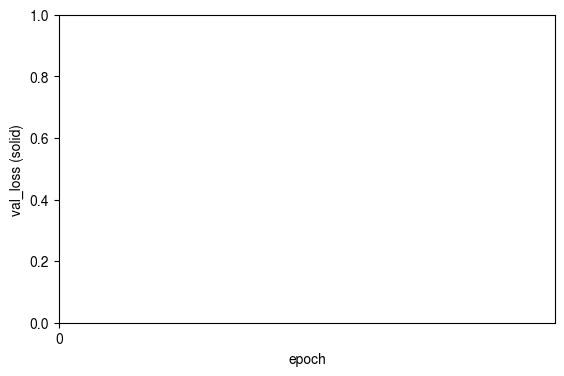

In [6]:
item1 = "val_loss"
item2 = "val_accuracy"

fig, ax1 = plt.subplots()
plt.xlabel("epoch")
plt.gca().xaxis.set_major_locator(MultipleLocator(10))

ax1.set_ylabel(item1 + " (solid)")
for i in range(len(label_ls)):
    plt.plot(x_range, npy_dict_ls[i][item1], label=label_ls[i])

ax2 = ax1.twinx()
ax2.set_ylabel(item2 + " (dashed)")
for i in range(len(label_ls)):
    plt.plot(x_range, npy_dict_ls[i][item2], "--", label=label_ls[i])

ax1.legend(loc="right")
plt.show()